# Trader Performance vs Market Sentiment
# Primetrade.ai Assignment
# Candidate: Dipesh Gosavi

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("Set2")

pd.set_option("display.max_columns", None)

%matplotlib inline

In [2]:
sentiment = pd.read_csv("../data/fear_greed_index.csv")
trades = pd.read_csv("../data/historical_data.csv")

In [3]:
print("Sentiment Dataset:", sentiment.shape)
print("Trader Dataset:", trades.shape)

Sentiment Dataset: (2644, 4)
Trader Dataset: (211224, 16)


In [4]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [7]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [8]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [9]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [10]:
print("Sentiment duplicates:", sentiment.duplicated().sum())

print("Trade duplicates:", trades.duplicated().sum())

Sentiment duplicates: 0
Trade duplicates: 0


In [11]:
sentiment["date"] = pd.to_datetime(sentiment["date"])

In [12]:
trades["Trade_Date"] = pd.to_datetime(
    trades["Timestamp"],
    unit="ms"
)

In [13]:
trades["Trade_Date"] = trades["Trade_Date"].dt.date

In [14]:
sentiment["Trade_Date"] = sentiment["date"].dt.date

In [15]:
trades[["Timestamp","Trade_Date"]].head()

,Timestamp,Trade_Date
0,1.730000e+12,2024-10-27
1,1.730000e+12,2024-10-27
2,1.730000e+12,2024-10-27
3,1.730000e+12,2024-10-27
4,1.730000e+12,2024-10-27


In [16]:
sentiment[["date","Trade_Date"]].head()

,date,Trade_Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [17]:
merged = trades.merge(
    sentiment[
        ["Trade_Date",
         "classification",
         "value"]
    ],
    on="Trade_Date",
    how="left"
)

In [18]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Trade_Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,Greed,74.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,Greed,74.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,Greed,74.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,Greed,74.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,Greed,74.0


In [19]:
merged.shape

(211224, 19)

In [20]:
merged.isnull().sum()

Account                 0
Coin                    0
Execution Price         0
Size Tokens             0
Size USD                0
Side                    0
Timestamp IST           0
Start Position          0
Direction               0
Closed PnL              0
Transaction Hash        0
Order ID                0
Crossed                 0
Fee                     0
Trade ID                0
Timestamp               0
Trade_Date              0
classification      26961
value               26961
dtype: int64

In [21]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(" ", "_")

trades.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,trade_date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27


In [22]:
trades["trade_datetime"] = pd.to_datetime(
    trades["timestamp_ist"],
    format="%d-%m-%Y %H:%M"
)

trades["trade_date"] = trades["trade_datetime"].dt.date

sentiment["date"] = pd.to_datetime(sentiment["date"])
sentiment["trade_date"] = sentiment["date"].dt.date

In [23]:
def sentiment_group(x):
    if "Fear" in x:
        return "Fear"
    elif "Greed" in x:
        return "Greed"
    else:
        return "Neutral"

sentiment["sentiment_group"] = sentiment["classification"].apply(sentiment_group)

sentiment[["trade_date", "value", "classification", "sentiment_group"]].head()

,trade_date,value,classification,sentiment_group
0,2018-02-01,30,Fear,Fear
1,2018-02-02,15,Extreme Fear,Fear
2,2018-02-03,40,Fear,Fear
3,2018-02-04,24,Extreme Fear,Fear
4,2018-02-05,11,Extreme Fear,Fear


In [24]:
merged = trades.merge(
    sentiment[["trade_date", "value", "classification", "sentiment_group"]],
    on="trade_date",
    how="left"
)

merged.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,trade_date,trade_datetime,value,classification,sentiment_group
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02 22:50:00,80.0,Extreme Greed,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024-12-02 22:50:00,80.0,Extreme Greed,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024-12-02 22:50:00,80.0,Extreme Greed,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024-12-02 22:50:00,80.0,Extreme Greed,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024-12-02 22:50:00,80.0,Extreme Greed,Greed


In [25]:
print("Merged shape:", merged.shape)
print("Missing sentiment rows:", merged["sentiment_group"].isnull().sum())

merged["sentiment_group"].value_counts(dropna=False)

Merged shape: (211224, 21)
Missing sentiment rows: 6


sentiment_group
Greed      90295
Fear       83237
Neutral    37686
NaN            6
Name: count, dtype: int64

In [26]:
merged["is_win"] = merged["closed_pnl"] > 0
merged["is_loss"] = merged["closed_pnl"] < 0

merged["trade_size_usd"] = merged["size_usd"]

merged["position_type"] = np.where(
    merged["direction"].str.contains("Long", case=False, na=False),
    "Long",
    np.where(
        merged["direction"].str.contains("Short", case=False, na=False),
        "Short",
        "Other"
    )
)

merged[["account", "coin", "closed_pnl", "trade_size_usd", "position_type", "sentiment_group"]].head()

,account,coin,closed_pnl,trade_size_usd,position_type,sentiment_group
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,7872.16,Other,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,127.68,Other,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,1150.63,Other,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,1142.04,Other,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,69.75,Other,Greed


In [27]:
daily_metrics = merged.groupby(["trade_date", "sentiment_group"]).agg(
    total_pnl=("closed_pnl", "sum"),
    avg_pnl=("closed_pnl", "mean"),
    total_trades=("trade_id", "count"),
    avg_trade_size=("trade_size_usd", "mean"),
    win_rate=("is_win", "mean"),
    total_fees=("fee", "sum")
).reset_index()

daily_metrics["win_rate"] = daily_metrics["win_rate"] * 100

daily_metrics.head()

,trade_date,sentiment_group,total_pnl,avg_pnl,total_trades,avg_trade_size,win_rate,total_fees
0,2023-05-01,Greed,0.000000,0.000000,3,159.000000,0.000000,0.000000
1,2023-12-05,Greed,0.000000,0.000000,9,5556.203333,0.000000,12.501455
2,2023-12-14,Greed,-205.434737,-18.675885,11,10291.213636,36.363636,28.300831
3,2023-12-15,Greed,-24.632034,-12.316017,2,5304.975000,0.000000,2.652489
4,2023-12-16,Greed,0.000000,0.000000,3,5116.256667,0.000000,3.837189


In [28]:
sentiment_performance = merged.groupby("sentiment_group").agg(
    total_pnl=("closed_pnl", "sum"),
    avg_pnl_per_trade=("closed_pnl", "mean"),
    median_pnl=("closed_pnl", "median"),
    win_rate=("is_win", "mean"),
    total_trades=("trade_id", "count"),
    avg_trade_size=("trade_size_usd", "mean"),
    total_fees=("fee", "sum")
).reset_index()

sentiment_performance["win_rate"] = sentiment_performance["win_rate"] * 100

sentiment_performance

,sentiment_group,total_pnl,avg_pnl_per_trade,median_pnl,win_rate,total_trades,avg_trade_size,total_fees
0,Fear,4.096266e+06,49.212077,0.0,40.787150,83237,7182.011019,116345.582614
1,Greed,4.865301e+06,53.882281,0.0,42.031120,90295,4574.424490,90129.357444
2,Neutral,1.292921e+06,34.307718,0.0,39.699093,37686,4782.732661,39374.268304


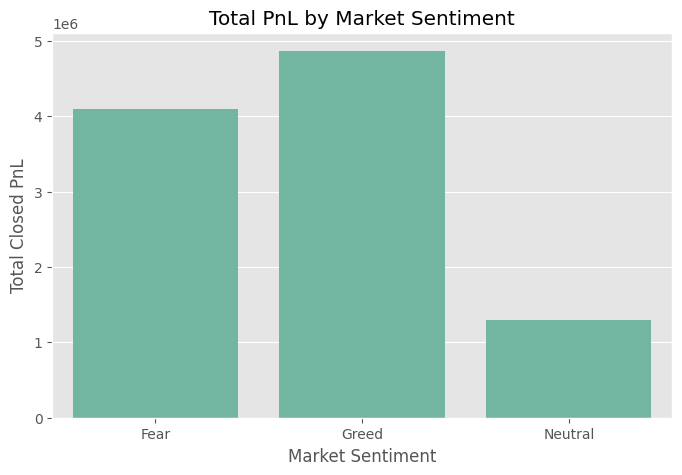

In [29]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=sentiment_performance,
    x="sentiment_group",
    y="total_pnl"
)

plt.title("Total PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")
plt.show()

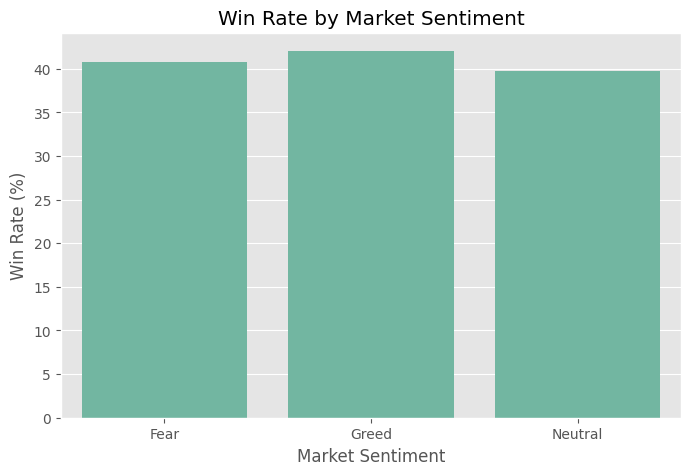

In [30]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=sentiment_performance,
    x="sentiment_group",
    y="win_rate"
)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.show()

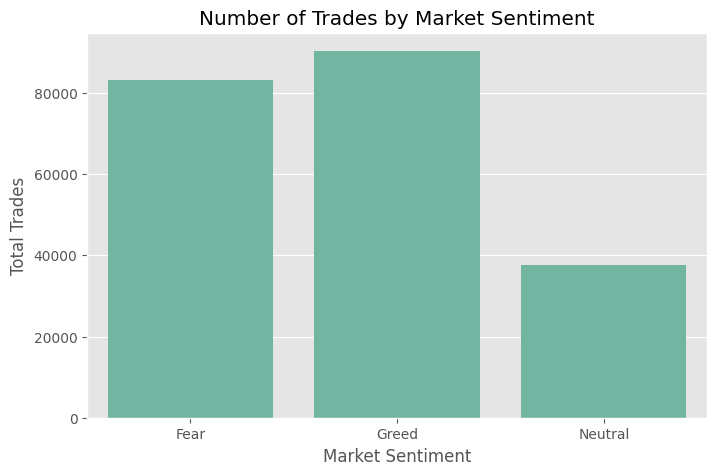

In [31]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=sentiment_performance,
    x="sentiment_group",
    y="total_trades"
)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Trades")
plt.show()

In [32]:
long_short_summary = merged.groupby(
    ["sentiment_group", "position_type"]
).agg(
    total_trades=("trade_id", "count"),
    total_pnl=("closed_pnl", "sum"),
    avg_pnl=("closed_pnl", "mean"),
    win_rate=("is_win", "mean"),
    avg_trade_size=("trade_size_usd", "mean")
).reset_index()

long_short_summary["win_rate"] = long_short_summary["win_rate"] * 100

long_short_summary

,sentiment_group,position_type,total_trades,total_pnl,avg_pnl,win_rate,avg_trade_size
0,Fear,Long,48373,1.947900e+06,40.268339,43.067414,8504.587409
1,Fear,Other,8465,-1.512597e+05,-17.868836,35.109273,1470.318005
2,Fear,Short,26399,2.299625e+06,87.110307,38.429486,6590.037600
3,Greed,Long,30085,1.159459e+06,38.539435,44.297823,7596.339288
4,Greed,Other,23063,2.905450e+06,125.978837,48.783766,1763.830333
5,Greed,Short,37147,8.003918e+05,21.546606,36.002907,3871.983547
6,Neutral,Long,20242,5.283548e+05,26.101907,42.624247,6148.828867
7,Neutral,Other,5241,2.100074e+05,40.070109,34.153787,1593.292572
8,Neutral,Short,12203,5.545584e+05,45.444434,37.228550,3886.505186


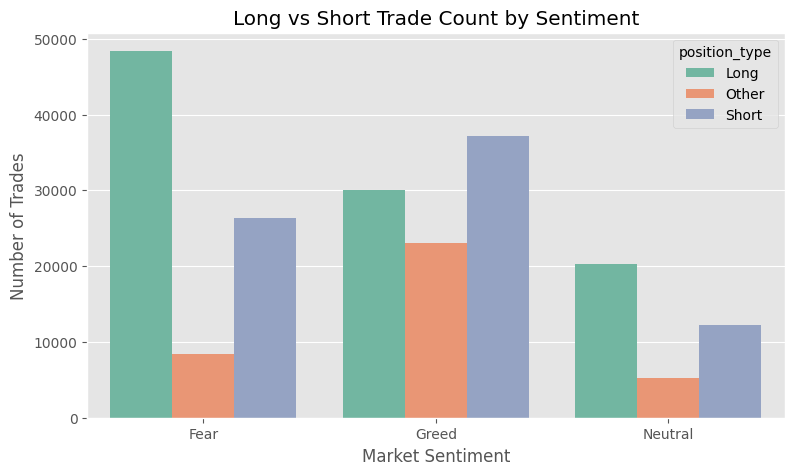

In [33]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=long_short_summary,
    x="sentiment_group",
    y="total_trades",
    hue="position_type"
)

plt.title("Long vs Short Trade Count by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

In [34]:
trader_summary = merged.groupby("account").agg(
    total_trades=("trade_id", "count"),
    total_pnl=("closed_pnl", "sum"),
    avg_pnl=("closed_pnl", "mean"),
    win_rate=("is_win", "mean"),
    avg_trade_size=("trade_size_usd", "mean"),
    total_fees=("fee", "sum"),
    active_days=("trade_date", "nunique")
).reset_index()

trader_summary["win_rate"] = trader_summary["win_rate"] * 100

trader_summary.head()

,account,total_trades,total_pnl,avg_pnl,win_rate,avg_trade_size,total_fees,active_days
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,35.961236,16159.576734,7405.312304,24
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,44.271978,1653.226327,2729.837889,52
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,30.191651,8893.000898,9280.982850,12
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,43.858463,507.626933,2218.367366,162
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,51.991355,3138.894782,3108.196722,69


In [35]:
trade_frequency_cutoff = trader_summary["total_trades"].median()
trade_size_cutoff = trader_summary["avg_trade_size"].median()

trader_summary["frequency_segment"] = np.where(
    trader_summary["total_trades"] >= trade_frequency_cutoff,
    "Frequent Trader",
    "Infrequent Trader"
)

trader_summary["size_segment"] = np.where(
    trader_summary["avg_trade_size"] >= trade_size_cutoff,
    "Large Size Trader",
    "Small Size Trader"
)

trader_summary["profitability_segment"] = np.where(
    trader_summary["total_pnl"] > 0,
    "Consistent Winner",
    "Inconsistent / Losing Trader"
)

trader_summary.head()

,account,total_trades,total_pnl,avg_pnl,win_rate,avg_trade_size,total_fees,active_days,frequency_segment,size_segment,profitability_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,35.961236,16159.576734,7405.312304,24,Frequent Trader,Large Size Trader,Consistent Winner
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,44.271978,1653.226327,2729.837889,52,Frequent Trader,Small Size Trader,Consistent Winner
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,30.191651,8893.000898,9280.982850,12,Frequent Trader,Large Size Trader,Inconsistent / Losing Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,43.858463,507.626933,2218.367366,162,Frequent Trader,Small Size Trader,Consistent Winner
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,51.991355,3138.894782,3108.196722,69,Infrequent Trader,Small Size Trader,Consistent Winner


In [36]:
frequency_segment_summary = trader_summary.groupby("frequency_segment").agg(
    number_of_traders=("account", "count"),
    total_pnl=("total_pnl", "sum"),
    avg_pnl_per_trader=("total_pnl", "mean"),
    avg_win_rate=("win_rate", "mean"),
    avg_trade_size=("avg_trade_size", "mean")
).reset_index()

frequency_segment_summary

,frequency_segment,number_of_traders,total_pnl,avg_pnl_per_trader,avg_win_rate,avg_trade_size
0,Frequent Trader,16,7.944443e+06,496527.661215,41.356208,7912.913954
1,Infrequent Trader,16,2.352516e+06,147032.272750,39.256304,4102.944786


In [37]:
profitability_segment_summary = trader_summary.groupby("profitability_segment").agg(
    number_of_traders=("account", "count"),
    total_pnl=("total_pnl", "sum"),
    avg_pnl_per_trader=("total_pnl", "mean"),
    avg_win_rate=("win_rate", "mean"),
    avg_trade_size=("avg_trade_size", "mean")
).reset_index()

profitability_segment_summary

,profitability_segment,number_of_traders,total_pnl,avg_pnl_per_trader,avg_win_rate,avg_trade_size
0,Consistent Winner,29,1.056622e+07,364352.408949,40.545268,6187.107321
1,Inconsistent / Losing Trader,3,-2.692609e+05,-89753.638695,37.995804,4275.875845


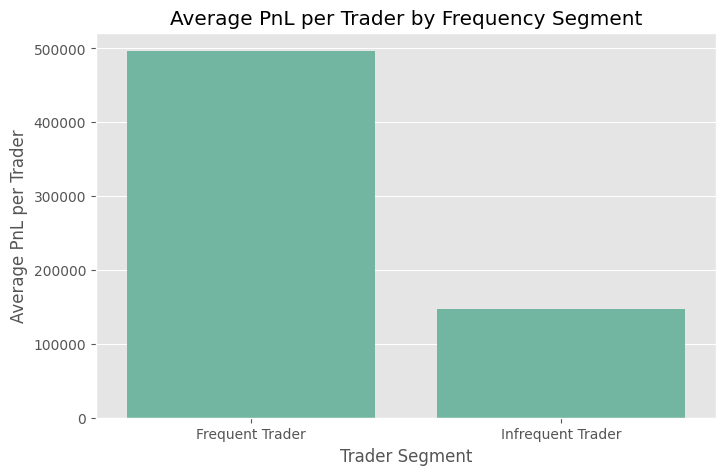

In [38]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=frequency_segment_summary,
    x="frequency_segment",
    y="avg_pnl_per_trader"
)

plt.title("Average PnL per Trader by Frequency Segment")
plt.xlabel("Trader Segment")
plt.ylabel("Average PnL per Trader")
plt.show()

In [39]:
sentiment_performance.to_csv("../outputs/tables/sentiment_performance.csv", index=False)
long_short_summary.to_csv("../outputs/tables/long_short_summary.csv", index=False)
trader_summary.to_csv("../outputs/tables/trader_summary.csv", index=False)
frequency_segment_summary.to_csv("../outputs/tables/frequency_segment_summary.csv", index=False)
profitability_segment_summary.to_csv("../outputs/tables/profitability_segment_summary.csv", index=False)

In [40]:
sentiment_performance

,sentiment_group,total_pnl,avg_pnl_per_trade,median_pnl,win_rate,total_trades,avg_trade_size,total_fees
0,Fear,4.096266e+06,49.212077,0.0,40.787150,83237,7182.011019,116345.582614
1,Greed,4.865301e+06,53.882281,0.0,42.031120,90295,4574.424490,90129.357444
2,Neutral,1.292921e+06,34.307718,0.0,39.699093,37686,4782.732661,39374.268304


In [41]:
long_short_summary

,sentiment_group,position_type,total_trades,total_pnl,avg_pnl,win_rate,avg_trade_size
0,Fear,Long,48373,1.947900e+06,40.268339,43.067414,8504.587409
1,Fear,Other,8465,-1.512597e+05,-17.868836,35.109273,1470.318005
2,Fear,Short,26399,2.299625e+06,87.110307,38.429486,6590.037600
3,Greed,Long,30085,1.159459e+06,38.539435,44.297823,7596.339288
4,Greed,Other,23063,2.905450e+06,125.978837,48.783766,1763.830333
5,Greed,Short,37147,8.003918e+05,21.546606,36.002907,3871.983547
6,Neutral,Long,20242,5.283548e+05,26.101907,42.624247,6148.828867
7,Neutral,Other,5241,2.100074e+05,40.070109,34.153787,1593.292572
8,Neutral,Short,12203,5.545584e+05,45.444434,37.228550,3886.505186


In [42]:
frequency_segment_summary

,frequency_segment,number_of_traders,total_pnl,avg_pnl_per_trader,avg_win_rate,avg_trade_size
0,Frequent Trader,16,7.944443e+06,496527.661215,41.356208,7912.913954
1,Infrequent Trader,16,2.352516e+06,147032.272750,39.256304,4102.944786


In [43]:
profitability_segment_summary

,profitability_segment,number_of_traders,total_pnl,avg_pnl_per_trader,avg_win_rate,avg_trade_size
0,Consistent Winner,29,1.056622e+07,364352.408949,40.545268,6187.107321
1,Inconsistent / Losing Trader,3,-2.692609e+05,-89753.638695,37.995804,4275.875845


In [44]:
trader_summary.describe()

,total_trades,total_pnl,avg_pnl,win_rate,avg_trade_size,total_fees,active_days
count,32.000000,3.200000e+01,32.000000,32.000000,32.000000,32.000000,32.00000
mean,6600.750000,3.217800e+05,97.686296,40.306256,6007.929370,7683.053768,73.15625
std,8250.373724,4.948276e+05,134.917737,10.849806,7281.058575,15287.906732,72.72312
min,332.000000,-1.676211e+05,-38.286626,23.498695,507.626933,147.074763,12.00000
25%,1381.750000,4.689324e+04,8.871295,32.956218,2011.069878,697.437514,27.50000
50%,3699.000000,1.176551e+05,41.110486,39.196804,3327.972048,2441.607287,46.50000
75%,8862.500000,4.063941e+05,148.008640,45.296340,7375.525018,7560.482327,74.75000
max,40184.000000,2.143383e+06,520.902331,81.087638,34396.580284,76424.642892,321.00000
